[0: likelihood] INFO: Initialized Gaussian with 1 params
[0: likelihood] INFO: Param list: ['x1']
[0: likelihood] INFO: Param bounds: {'x1': [0, 1]}
[0: likelihood] INFO: Logprior volume = 0.0000
[0: prior] INFO: DSP Unscaled prior chosen
[0: prior] INFO: DSLP prior chosen
Fit SLK
[0: gp] INFO: Best MLL:  -1.0241158854731396
Fit RBF
[0: gp] INFO: Best MLL:  -24.083715615012974
[[-12.5]
 [-12.5]]
Fit SLK
[0: gp] INFO: Best MLL:  -959.702449333156
Fit RBF
[0: gp] INFO: Best MLL:  -26.815075166818957
[[-32.]
 [-32.]]
Fit SLK
[0: gp] INFO: Best MLL:  -1834.0509101778548
Fit RBF
[0: gp] INFO: Best MLL:  -28.314087535781184


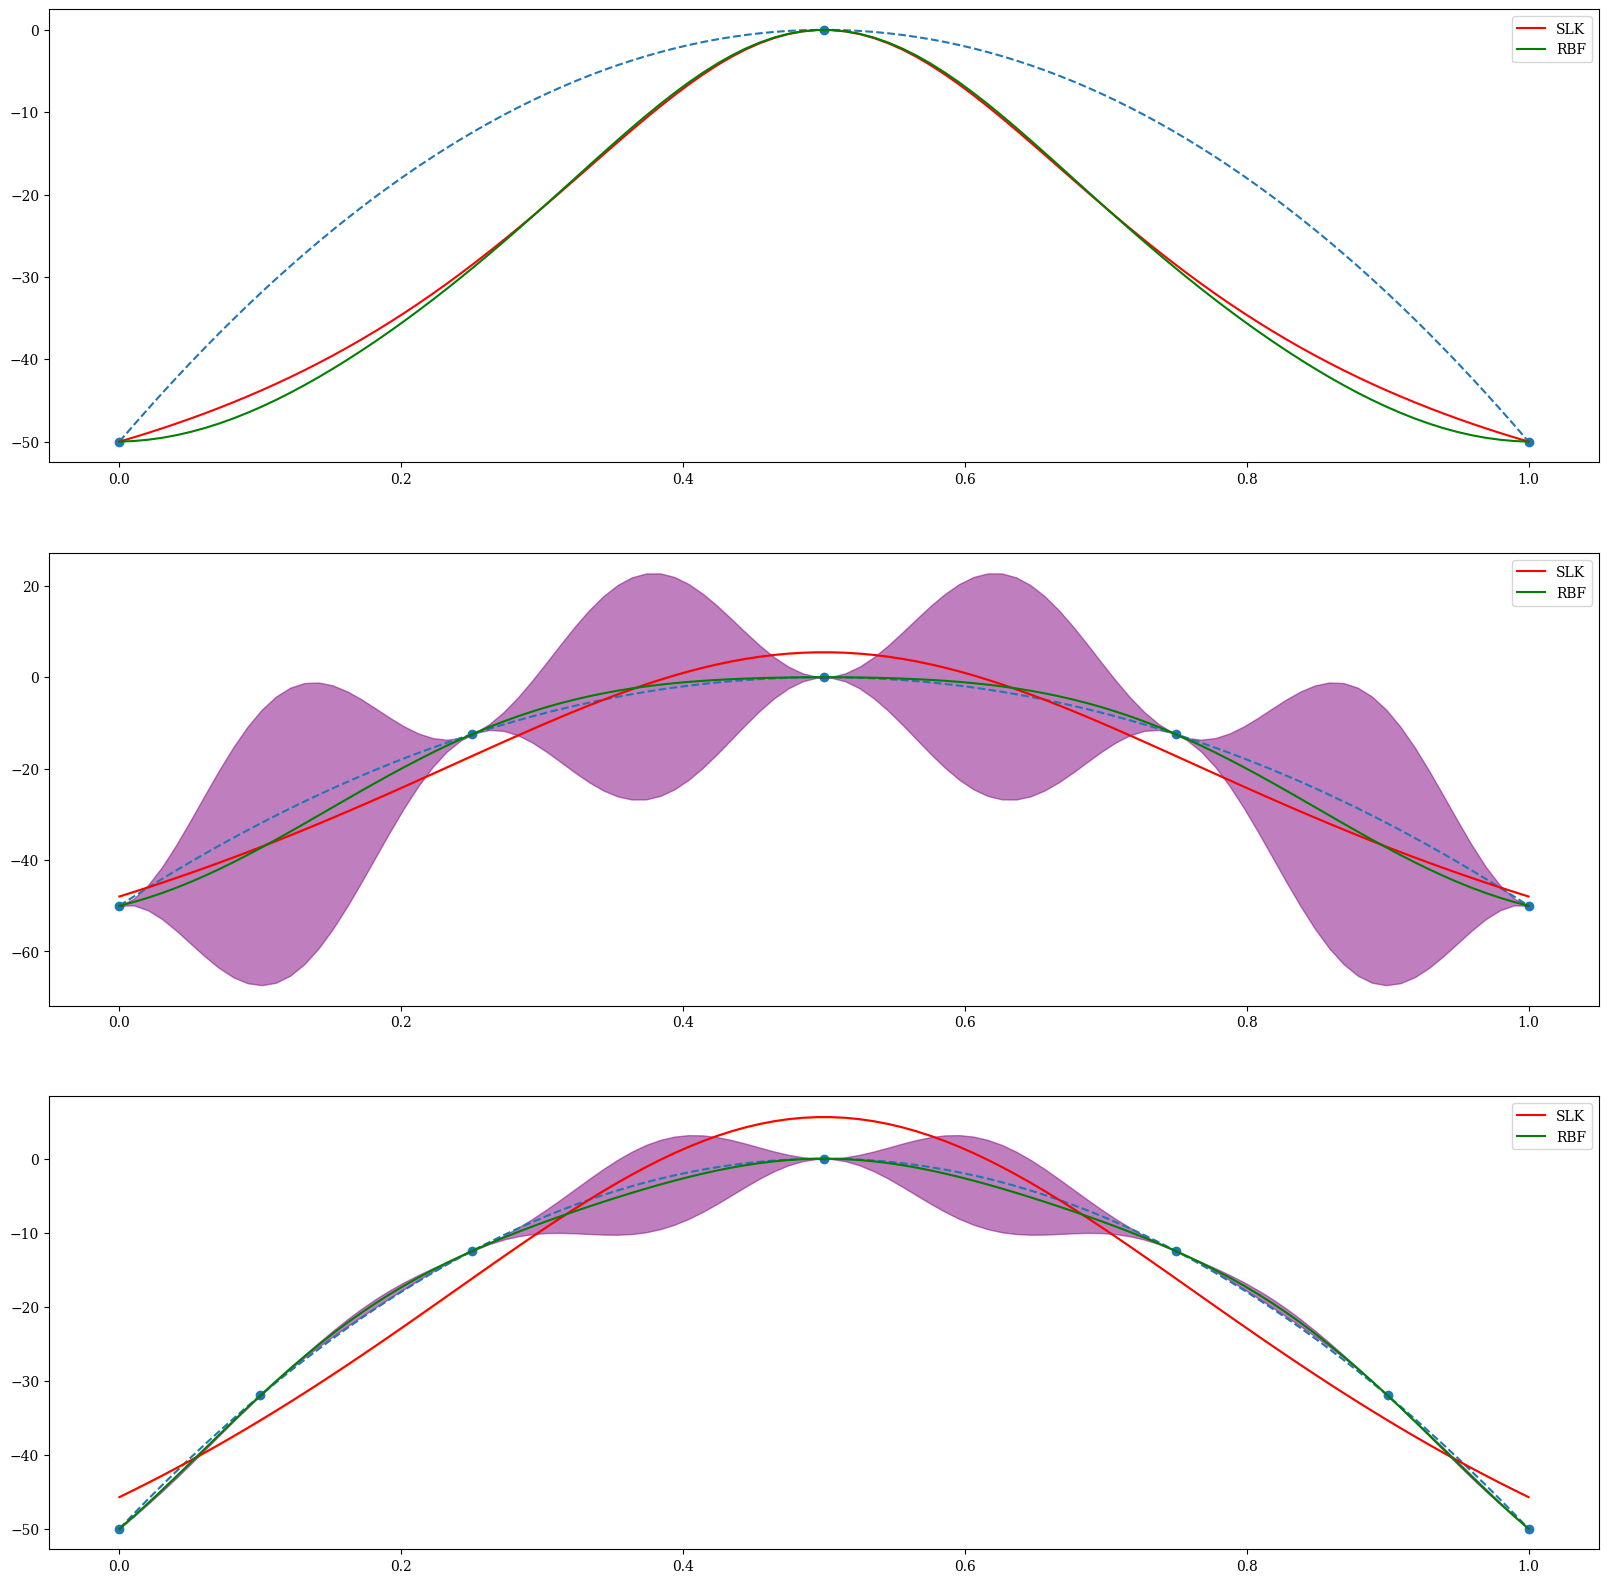

In [5]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '../JaxBo_GH/'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt


ndim=1
param_list = [f"x{j}" for j in range(1, ndim + 1)]
param_labels = [f"x_{j}" for j in range(1, ndim + 1)]
Gaussian_param_bounds = np.array([[0,1]]+[[0,1]]*(ndim-1)).T
def Gaussian_loglike(X, slow=False):
    # X is a N x DIM shaped tensor, output is N tensor
    mean = np.array(0.5)
    sigma = np.array(0.05)
    return -0.5*np.sum((X-mean)**2/sigma**2, axis=-1)


from BOBE.likelihood import Likelihood
from BOBE.utils.seed import get_numpy_rng
from BOBE.utils.core import scale_to_unit

np_rng = get_numpy_rng()
n_sobol_init = 2

likelihood=Gaussian_loglike
likelihood_kwargs={
            'param_list': param_list,
            'param_bounds': Gaussian_param_bounds,
            'param_labels': param_labels,
            'name': 'Gaussian',
}

loglikelihood = Likelihood(loglikelihood=likelihood, **likelihood_kwargs)

train_x = jnp.array(scale_to_unit(jnp.array([[0], [0.5], [1.0]]), loglikelihood.param_bounds))
train_y = []
for i in range(len(train_x)):
    train_y.append(jnp.array(loglikelihood(train_x[i])))

from BOBE.gp import GP

gp_kwargs_slk= {'lengthscale_prior': 'dsp_unscaled', 'kernel':'spherical_linear', 'noise': 1e-4}
gp_kwargs_slk.update({'train_x': jnp.atleast_2d(train_x), 'train_y': jnp.atleast_2d(train_y).T, 'param_names': loglikelihood.param_list})
gp_slk = GP(**gp_kwargs_slk)

gp_kwargs_rbf= {'lengthscale_prior': 'DSLP', 'kernel':'rbf'}
gp_kwargs_rbf.update({'train_x': jnp.atleast_2d(train_x), 'train_y': jnp.atleast_2d(train_y).T, 'param_names': loglikelihood.param_list})
gp_rbf = GP(**gp_kwargs_rbf)

print("Fit SLK")
gp_slk.fit()
print("Fit RBF")
gp_rbf.fit()

%matplotlib inline

x_pred = np.linspace(0, 1, 100)


func = jnp.array([loglikelihood(x) for x in x_pred])
mean_slk = jnp.array([gp_slk.predict_mean_single(x) for x in x_pred])
var_slk = jnp.array([gp_slk.predict_var_single(x) for x in x_pred])

mean_rbf = jnp.array([gp_rbf.predict_mean_single(x) for x in x_pred])
var_rbf = jnp.array([gp_rbf.predict_var_single(x) for x in x_pred])

fig, ax = plt.subplots(3, 1, figsize=(20, 20))
ax[0].plot(x_pred, func, ls='--')
ax[0].scatter(gp_rbf.train_x[:, 0], gp_rbf.train_y[:, 0]*gp_rbf.y_std + gp_rbf.y_mean)
ax[0].plot(x_pred, mean_slk, color='red', label='SLK')
#plt.fill_between(x_pred, mean_slk + var_slk, mean_slk-var_slk, alpha=0.5, color='orange')

ax[0].plot(x_pred, mean_rbf, color='green', label='RBF')
#plt.fill_between(x_pred, mean_rbf + var_rbf, mean_rbf-var_rbf, alpha=0.5, color='purple')

new_x = jnp.array([[0.25], [0.75]])
new_y = jnp.array([loglikelihood(x) for x in new_x])[:, None]

print(new_y)

gp_slk.update(new_x=new_x, new_y=new_y)
gp_rbf.update(new_x=new_x, new_y=new_y)

print("Fit SLK")
gp_slk.fit()
print("Fit RBF")
gp_rbf.fit()

mean_slk = jnp.array([gp_slk.predict_mean_single(x) for x in x_pred])
var_slk = jnp.array([gp_slk.predict_var_single(x) for x in x_pred])

mean_rbf = jnp.array([gp_rbf.predict_mean_single(x) for x in x_pred])
var_rbf = jnp.array([gp_rbf.predict_var_single(x) for x in x_pred])

ax[1].plot(x_pred, func, ls='--')
ax[1].scatter(gp_rbf.train_x, gp_rbf.train_y*gp_rbf.y_std + gp_rbf.y_mean)
ax[1].plot(x_pred, mean_slk, color='red', label='SLK')
ax[1].fill_between(x_pred, mean_slk + var_slk, mean_slk-var_slk, alpha=0.5, color='orange')

ax[1].plot(x_pred, mean_rbf, color='green', label='RBF')
ax[1].fill_between(x_pred, mean_rbf + var_rbf, mean_rbf-var_rbf, alpha=0.5, color='purple')


new_x = jnp.array([[0.1], [0.9]])
new_y = jnp.array([loglikelihood(x) for x in new_x])[:, None]

print(new_y)

gp_slk.update(new_x=new_x, new_y=new_y)
gp_rbf.update(new_x=new_x, new_y=new_y)

print("Fit SLK")
gp_slk.fit()
print("Fit RBF")
gp_rbf.fit()

mean_slk = jnp.array([gp_slk.predict_mean_single(x) for x in x_pred])
var_slk = jnp.array([gp_slk.predict_var_single(x) for x in x_pred])

mean_rbf = jnp.array([gp_rbf.predict_mean_single(x) for x in x_pred])
var_rbf = jnp.array([gp_rbf.predict_var_single(x) for x in x_pred])

ax[2].plot(x_pred, func, ls='--')
ax[2].scatter(gp_rbf.train_x, gp_rbf.train_y*gp_rbf.y_std + gp_rbf.y_mean)
ax[2].plot(x_pred, mean_slk, color='red', label='SLK')
ax[2].fill_between(x_pred, mean_slk + var_slk, mean_slk-var_slk, alpha=0.5, color='orange')

ax[2].plot(x_pred, mean_rbf, color='green', label='RBF')
ax[2].fill_between(x_pred, mean_rbf + var_rbf, mean_rbf-var_rbf, alpha=0.5, color='purple')

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()
